Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Integration: Loading datasets complete
Data Integration: Merging complete
Merged dataset shape: (950, 38)
Data Cleaning: Missing and invalid records removed
Feature Engineering: Completed
Data Analysis
Mean delay: 10.317150847061708
Median delay: 7.913108956111111

Exploratory Analysis
Driver performance:
 driver_id
D081    25.339633
D063    21.729182
D095    21.515055
D062    21.022703
D040    18.743702
D023    18.632475
D055    18.492042
D022    18.018141
D057    17.809027
D144    17.755930
Name: delay_hours, dtype: float64

Route performance:
 route
CENTRAL -> South        31.637925
Ctr -> NORTH            27.003118
AIRPORT -> Riverside    23.001071
SOUTH -> WEST           22.471346
CENTRAL -> EAST         22.368022
RiverSide -> North      22.223440
WEST -> RiverSide       21.943376
RiverSide -> Central    21.404982
NORTH -> Airport        20.989598
E

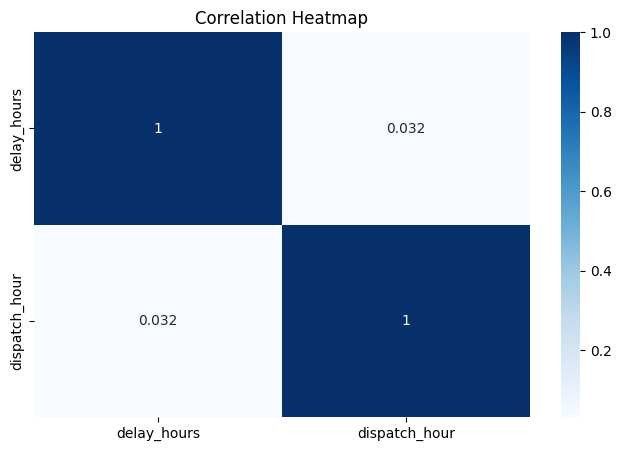

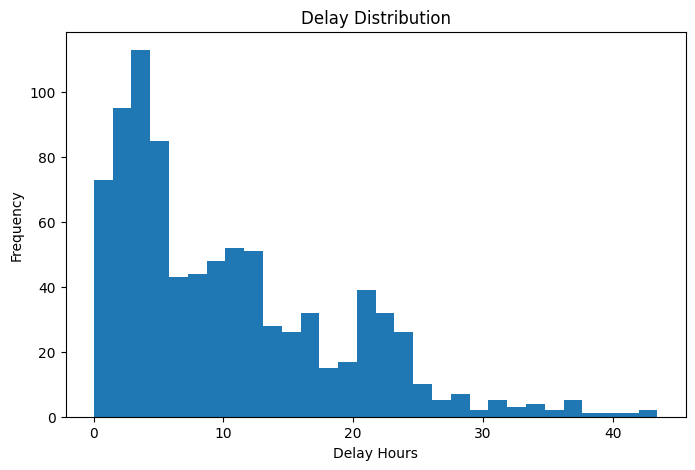

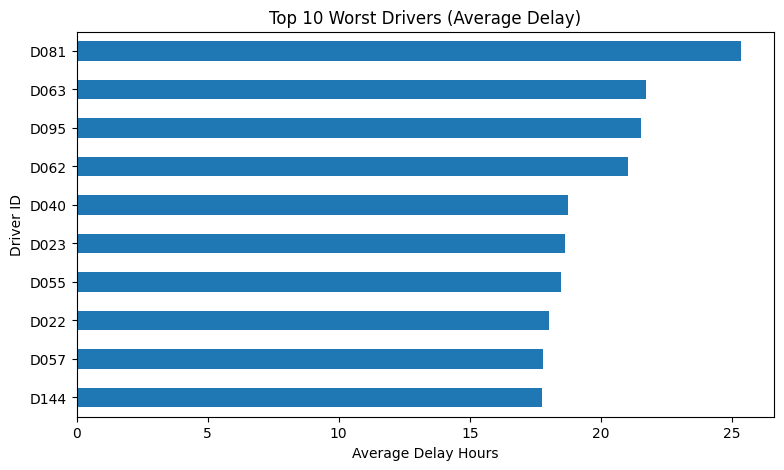

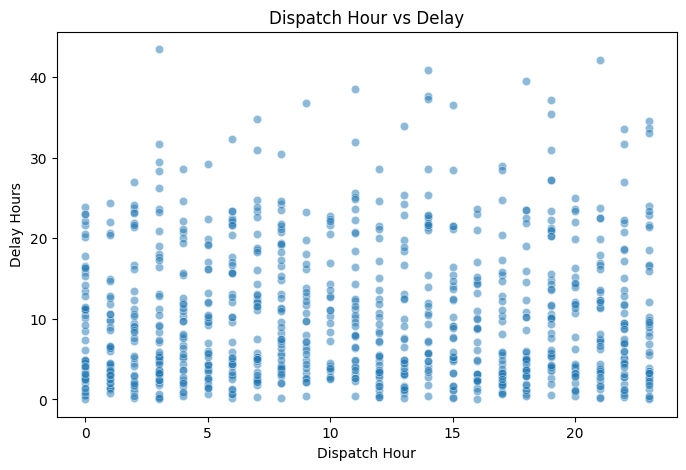

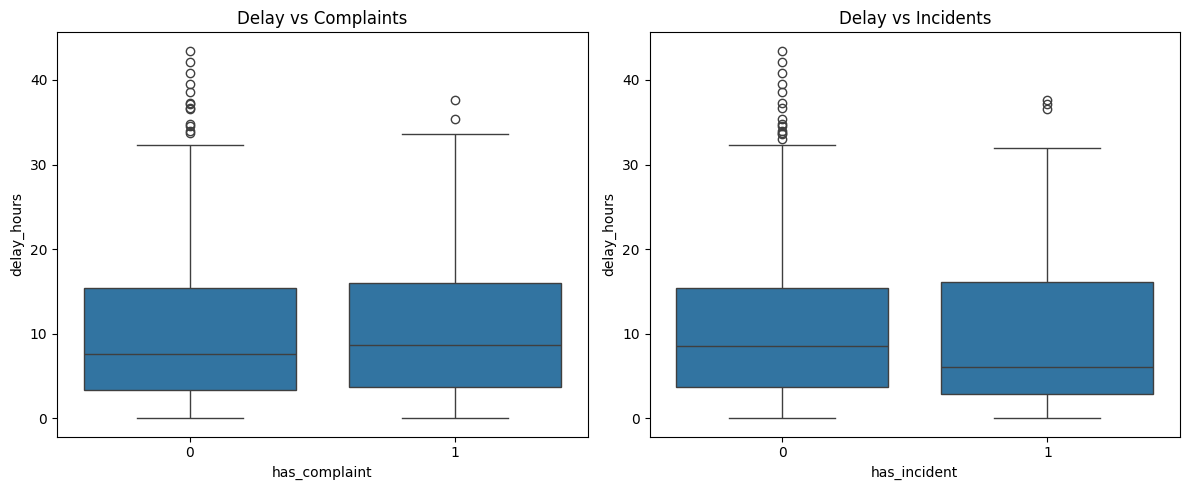

Cleaned Data: Export completed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/DA Assignment/data"

orders = pd.read_csv(path + "/orders.csv")
deliveries = pd.read_csv(path + "/deliveries.csv")
drivers = pd.read_csv(path + "/drivers.csv")
customers = pd.read_csv(path + "/customers.csv")
complaints = pd.read_csv(path + "/complaints.csv")
incidents = pd.read_csv(path + "/incidents.csv")
hubs = pd.read_csv(path + "/hubs.csv")
vehicles = pd.read_csv(path + "/vehicles.csv")
app_events = pd.read_csv(path + "/app_events.csv")
data_dictionary = pd.read_csv(path + "/data_dictionary.csv")

print("Data Integration: Loading Datasets Complete")

df = orders.merge(deliveries, on="order_id", how="inner")
df = df.merge(drivers, on="driver_id", how="left")
df = df.merge(customers, on="customer_id", how="left")

print("Data Integration: Merging Complete")
print("Merged Dataset Shape:", df.shape)

df = df.dropna(subset=["dispatch_time", "delivery_completed_at"])

df["dispatch_time"] = pd.to_datetime(df["dispatch_time"])
df["delivery_completed_at"] = pd.to_datetime(df["delivery_completed_at"])

df = df[df["delivery_completed_at"] >= df["dispatch_time"]]

print("Data Cleaning: Missing and Invalid Records Removed")

df["delay_hours"] = (
    df["delivery_completed_at"] - df["dispatch_time"]
).dt.total_seconds() / 3600

df["route"] = df["pickup_zone"] + " -> " + df["dropoff_zone"]
df["dispatch_hour"] = df["dispatch_time"].dt.hour

df["has_complaint"] = df["order_id"].isin(complaints["order_id"]).astype(int)
df["has_incident"] = df["delivery_id"].isin(incidents["delivery_id"]).astype(int)

print("Feature Engineering: Completed")

mean_delay = np.mean(df["delay_hours"])
median_delay = np.median(df["delay_hours"])

print("Data Analysis")
print("Mean Delay:", mean_delay)
print("Median Delay:", median_delay)

driver_analysis = (
    df.groupby("driver_id")["delay_hours"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

route_analysis = (
    df.groupby("route")["delay_hours"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nExploratory Analysis")
print("Driver Performance:\n", driver_analysis)
print("\nRoute Performance:\n", route_analysis)

print("\nComplaint Impact:\n", df.groupby("has_complaint")["delay_hours"].mean())
print("Incident Impact:\n", df.groupby("has_incident")["delay_hours"].mean())

corr = df[["delay_hours", "dispatch_hour"]].corr()
print("\nCorrelation Analysis:\n", corr)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["delay_hours"], bins=30)
plt.title("Delay Distribution")
plt.xlabel("Delay Hours")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(9, 5))
driver_analysis.sort_values().plot(kind="barh")
plt.title("Top 10 Worst Drivers (Average Delay)")
plt.xlabel("Average Delay Hours")
plt.ylabel("Driver ID")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="dispatch_hour", y="delay_hours", alpha=0.5)
plt.title("Dispatch Hour vs Delay")
plt.xlabel("Dispatch Hour")
plt.ylabel("Delay Hours")
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="has_complaint", y="delay_hours")
plt.title("Delay vs Complaints")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="has_incident", y="delay_hours")
plt.title("Delay vs Incidents")

plt.tight_layout()
plt.show()

df.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned Data: Export Completed")